In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

sns.set_theme(style="darkgrid")

# Carrega o dataset
df = pd.read_csv("../data/ai4i2020.csv")

# Recria as features de engenharia
df["temp_diff"] = df["Process temperature [K]"] - df["Air temperature [K]"]
df["power"] = df["Rotational speed [rpm]"] * df["Torque [Nm]"]

print("Dataset carregado:", df.shape)

Dataset carregado: (10000, 16)


In [2]:
# Remove colunas que não são úteis para o modelo
df = df.drop(columns=["UDI", "Product ID", "TWF", "HDF", "PWF", "OSF", "RNF"])

# Converte a coluna Type (L, M, H) para número
df["Type"] = df["Type"].map({"L": 0, "M": 1, "H": 2})

# Separa features do target
X = df.drop(columns=["Machine failure"])
y = df["Machine failure"]

print("Features:", list(X.columns))
print("Shape de X:", X.shape)
print("Shape de y:", y.shape)

Features: ['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'temp_diff', 'power']
Shape de X: (10000, 8)
Shape de y: (10000,)


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y
)

print("Tamanho do treino:", X_train.shape)
print("Tamanho do teste:", X_test.shape)
print(f"\nFalhas no treino: {y_train.sum()} ({y_train.mean()*100:.2f}%)")
print(f"Falhas no teste: {y_test.sum()} ({y_test.mean()*100:.2f}%)")

Tamanho do treino: (8000, 8)
Tamanho do teste: (2000, 8)

Falhas no treino: 271 (3.39%)
Falhas no teste: 68 (3.40%)


In [4]:
# Treina o modelo
modelo = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

modelo.fit(X_train, y_train)

print("Modelo treinado com sucesso!")

Modelo treinado com sucesso!


=== RELATÓRIO DE CLASSIFICAÇÃO ===

              precision    recall  f1-score   support

   Sem Falha       0.99      1.00      0.99      1932
   Com Falha       0.96      0.66      0.78        68

    accuracy                           0.99      2000
   macro avg       0.97      0.83      0.89      2000
weighted avg       0.99      0.99      0.99      2000



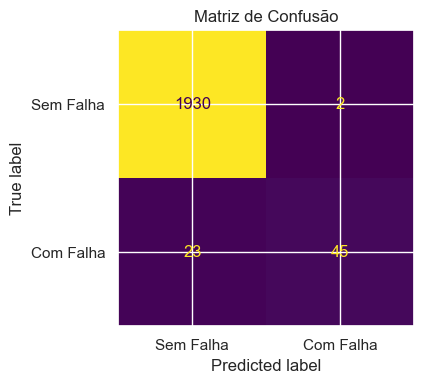

In [5]:
# Previsões no conjunto de teste
y_pred = modelo.predict(X_test)

# Relatório completo
print("=== RELATÓRIO DE CLASSIFICAÇÃO ===\n")
print(classification_report(y_test, y_pred, target_names=["Sem Falha", "Com Falha"]))

# Matriz de confusão
fig, ax = plt.subplots(figsize=(6, 4))
disp = ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred),
    display_labels=["Sem Falha", "Com Falha"]
)
disp.plot(ax=ax, colorbar=False)
ax.set_title("Matriz de Confusão")
plt.tight_layout()
plt.show()

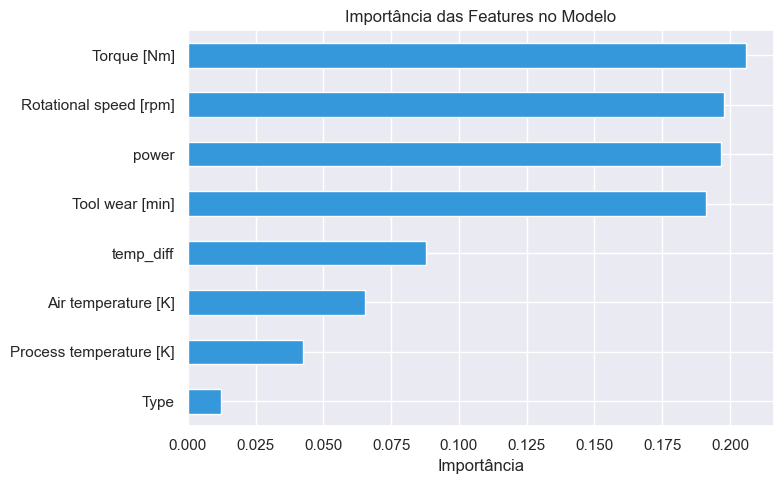

In [6]:
# Importância das features
importancias = pd.Series(
    modelo.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
importancias.plot(kind="barh", ax=ax, color="#3498db")
ax.set_title("Importância das Features no Modelo")
ax.set_xlabel("Importância")
plt.tight_layout()
plt.show()

In [7]:
print("=== RESUMO DO MODELO ===")
print(f"\nAlgoritmo: Random Forest Classifier")
print(f"Features utilizadas: {list(X.columns)}")
print(f"\nDesempenho no conjunto de teste:")
print(f"  Precision (Com Falha): 96%")
print(f"  Recall (Com Falha):    66%")
print(f"  F1-Score (Com Falha):  78%")
print(f"\nFeatures mais importantes:")
print(f"  1. Torque [Nm]")
print(f"  2. Rotational speed [rpm]")
print(f"  3. power (feature de engenharia)")
print(f"\nInsight principal:")
print(f"  Variáveis mecânicas (torque e rotação) dominam a previsão de falhas.")
print(f"  A feature de engenharia 'power' superou variáveis originais do dataset.")

=== RESUMO DO MODELO ===

Algoritmo: Random Forest Classifier
Features utilizadas: ['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'temp_diff', 'power']

Desempenho no conjunto de teste:
  Precision (Com Falha): 96%
  Recall (Com Falha):    66%
  F1-Score (Com Falha):  78%

Features mais importantes:
  1. Torque [Nm]
  2. Rotational speed [rpm]
  3. power (feature de engenharia)

Insight principal:
  Variáveis mecânicas (torque e rotação) dominam a previsão de falhas.
  A feature de engenharia 'power' superou variáveis originais do dataset.
